# ANN (MLP) model  with validation figures

Runs the ANN AlphaEarth-only,
for all four crops 




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
CROPS = ['Barley', 'Maize', 'Millet', 'Wheat']


## 1. Dataset paths — confirmed against your actual files

In [2]:
DATASET_PATHS = {
    'Alpha-only':       r"/Users/macbook/Downloads/Alpha_earth/merged_dataset/nepal_alpha_merged_dataset_without_buckwheat.csv"}
DISTRICT_COL = 'District'
YEAR_COL = 'Year_AD'
YIELD_COL_TEMPLATE = '{crop}_Yield_MtHa'
CATEGORICAL_COLS = ['Landform', 'Parent_Material', 'Dominant_Soil']


## 2. Data loading and evaluation functions

In [3]:
def get_crop_data(crop, data_path):
    df = pd.read_csv(data_path, dtype=str)
    df.columns = [c.strip() for c in df.columns]
    for c in df.columns:
        df[c] = df[c].str.strip()

    id_like = ['District_Key', 'District', 'Year_BS', 'Province',
               'Landform', 'Parent_Material', 'Dominant_Soil']
    for col in df.columns:
        if col not in id_like:
            df[col] = pd.to_numeric(df[col].replace({'N/A': None}), errors='coerce')

    yield_col = YIELD_COL_TEMPLATE.format(crop=crop)
    df = df.sort_values([DISTRICT_COL, YEAR_COL])

    real_counts = df.groupby(DISTRICT_COL)[yield_col].transform('count')
    df = df[real_counts > 0].copy()

    df['is_interpolated'] = df[yield_col].isna()          # <-- flag BEFORE filling
    df[yield_col] = df.groupby(DISTRICT_COL)[yield_col].transform(
        lambda s: s.interpolate(method='linear', limit_direction='both')
    )

    target_like = [c for c in df.columns
                   if any(tok in c for tok in ['_Area_Ha', '_Production_Mt', '_Yield_MtHa'])]
    drop_cols = list(dict.fromkeys(id_like + ['Year_AD'] + [c for c in target_like if c != yield_col]))

    X = df.drop(columns=[c for c in drop_cols if c in df.columns] + [yield_col, 'is_interpolated'])
    y = df[yield_col]
    is_interp = df['is_interpolated']
    groups_district = df[DISTRICT_COL]
    groups_year = df[YEAR_COL]
    return X, y, groups_district, groups_year, is_interp


def evaluate_groupcv(model_ctor, X, y, groups, n_splits, is_interp=None):
    gkf = GroupKFold(n_splits=n_splits)
    y_true_all, y_pred_all = [], []
    for train_idx, test_idx in gkf.split(X, y, groups):
        model = model_ctor()
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = model.predict(X.iloc[test_idx])
        if is_interp is not None:
            genuine_mask = ~is_interp.iloc[test_idx].values
        else:
            genuine_mask = np.ones(len(test_idx), dtype=bool)
        y_true_all.extend(y.iloc[test_idx].values[genuine_mask].tolist())
        y_pred_all.extend(preds[genuine_mask].tolist())
    y_true_all, y_pred_all = np.array(y_true_all), np.array(y_pred_all)
    r2 = r2_score(y_true_all, y_pred_all)
    rmse = mean_squared_error(y_true_all, y_pred_all, squared=False)
    return r2, rmse, y_true_all, y_pred_all
def encode_categoricals(X):
    present_cat_cols = [c for c in CATEGORICAL_COLS if c in X.columns]
    if not present_cat_cols:
        return X
    return pd.get_dummies(X, columns=present_cat_cols, drop_first=False)



## 3. Feature selection (self-contained, no external RFECV needed)

`RFECV` cannot run on an MLP directly (no `coef_`/`feature_importances_`), so this
uses permutation-importance-based elimination, native to the ANN and requiring
nothing from your other notebooks. Runs once per crop per dataset, same as RFECV
would in the other models.


In [4]:
def rfecv_permutation(build_model, X, y, groups, min_features=5, step=5,
                       cv_splits=5, n_repeats=5, random_state=RANDOM_STATE):
    """Recursive feature elimination with proper CV-score-based selection, for estimators
    with no coef_/feature_importances_ (e.g. MLPRegressor). At each elimination step the
    current feature set is scored via k-fold GroupKFold CV (averaged across folds, not a
    single split); permutation importance is likewise averaged across folds to decide which
    features to drop next. The feature subset achieving the best mean CV R^2 across the whole
    elimination trajectory is returned -- not simply the smallest surviving set."""
    features = list(X.columns)
    n_splits = min(cv_splits, groups.nunique())
    gkf = GroupKFold(n_splits=n_splits)
    folds = list(gkf.split(X, y, groups))

    def score_and_importance(feats):
        fold_scores = []
        importances_accum = pd.Series(0.0, index=feats)
        for train_idx, val_idx in folds:
            model = build_model()
            model.fit(X.iloc[train_idx][feats], y.iloc[train_idx])
            fold_scores.append(model.score(X.iloc[val_idx][feats], y.iloc[val_idx]))
            result = permutation_importance(model, X.iloc[val_idx][feats], y.iloc[val_idx],
                                             n_repeats=n_repeats, random_state=random_state,
                                             scoring='r2')
            importances_accum += pd.Series(result.importances_mean, index=feats)
        return np.mean(fold_scores), importances_accum / n_splits

    history = []  # (n_features, mean_r2, feature_list)
    while True:
        mean_r2, importances = score_and_importance(features)
        history.append((len(features), mean_r2, list(features)))
        if len(features) <= min_features:
            break
        n_drop = min(step, len(features) - min_features)
        to_drop = importances.sort_values().index[:n_drop].tolist()
        features = [f for f in features if f not in to_drop]

    best_n, best_r2, best_features = max(history, key=lambda h: h[1])
    return best_features

## 4. ANN model definitions

In [5]:
def model_ctor():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(
            hidden_layer_sizes=(64,32,16,8), activation='relu', solver='adam',
            alpha=1e-1, learning_rate_init=1e-2, max_iter=2000,
            early_stopping=True, validation_fraction=0.15, n_iter_no_change=20,
            random_state=RANDOM_STATE,
        )),
    ])

def rfe_model_ctor():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(
            hidden_layer_sizes=(32,16), activation='relu', solver='adam',
            alpha=1e-1, max_iter=500, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=10, random_state=RANDOM_STATE,
        )),
    ])


## 5. Main loop — all three datasets, all four crops

Produces `results_ann[dataset_name]` (a DataFrame, one row per crop — analogous
to your Tables I/II/III) and `lodo_oof_ann[dataset_name][crop]` (out-of-fold
LODO predictions, used for the scatter plots below).


In [6]:
results_ann = {}
loyo_oof_ann = {}
fitted_ann = {}

for dataset_name, data_path in DATASET_PATHS.items():
    print('#' * 70)
    print(dataset_name)
    print('#' * 70)
    rows = []
    loyo_oof_ann[dataset_name] = {}
    fitted_ann[dataset_name] = {}

    for crop in CROPS:
        print('-' * 50)
        print(crop)
        X, y, groups_district, groups_year, is_interp = get_crop_data(crop, data_path)
        X_encoded = encode_categoricals(X)
        n_samples = len(y)
        n_districts = groups_district.nunique()
        n_years = groups_year.nunique()
        print(f'n_samples={n_samples}  n_districts={n_districts}  n_years={n_years}')

        selected_features = rfecv_permutation(rfe_model_ctor, X_encoded, y, groups_district)
        X_sel = X_encoded[selected_features]
        print(f'Selected {len(selected_features)} / {X_encoded.shape[1]} features')
        print(f'Selected features for {crop}: {selected_features}')

        r2_loyo, rmse_loyo, y_true_loyo, y_pred_loyo = evaluate_groupcv(
            model_ctor, X_sel, y, groups_year, n_splits=n_years, is_interp=is_interp)

        print(f'LOYO  R2={r2_loyo:.3f}  RMSE={rmse_loyo:.3f}')

        loyo_oof_ann[dataset_name][crop] = (y_true_loyo, y_pred_loyo)

        final_model = model_ctor()
        final_model.fit(X_sel, y)
        fitted_ann[dataset_name][crop] = final_model

        rows.append({
            'Crop': crop, 'N_samples': n_samples, 'N_features_selected': len(selected_features),
            'LOYO_R2': r2_loyo, 'LOYO_RMSE': rmse_loyo,
        })

    results_ann[dataset_name] = pd.DataFrame(rows)

######################################################################
Alpha-only
######################################################################
--------------------------------------------------
Barley
n_samples=380  n_districts=76  n_years=5
Selected 5 / 64 features
Selected features for Barley: ['A21', 'A42', 'A45', 'A46', 'A56']
LOYO  R2=0.078  RMSE=0.393
--------------------------------------------------
Maize
n_samples=385  n_districts=77  n_years=5
Selected 14 / 64 features
Selected features for Maize: ['A00', 'A02', 'A05', 'A15', 'A17', 'A20', 'A21', 'A23', 'A28', 'A34', 'A37', 'A55', 'A57', 'A61']
LOYO  R2=0.422  RMSE=0.637
--------------------------------------------------
Millet
n_samples=365  n_districts=73  n_years=5
Selected 24 / 64 features
Selected features for Millet: ['A04', 'A05', 'A07', 'A14', 'A16', 'A17', 'A25', 'A28', 'A30', 'A34', 'A35', 'A36', 'A38', 'A42', 'A43', 'A44', 'A47', 'A49', 'A53', 'A56', 'A57', 'A60', 'A62', 'A63']
LOYO  R2=0.010  RMSE=0.252


## 6. Results tables — one per dataset (analogous to Tables I–III)

In [7]:
for dataset_name, df in results_ann.items():
    print(dataset_name)
    display(df)


Alpha-only


,Crop,N_samples,N_features_selected,LOYO_R2,LOYO_RMSE
0,Barley,380,5,0.077643,0.393403
1,Maize,385,14,0.421993,0.636909
2,Millet,365,24,0.009624,0.252364
3,Wheat,385,59,0.568947,0.529455


## 7. Validation figures — LODO vs. LOYO R² by crop, per dataset

Same style as your Fig. 1/2/3 grouped bar charts, one figure per dataset.


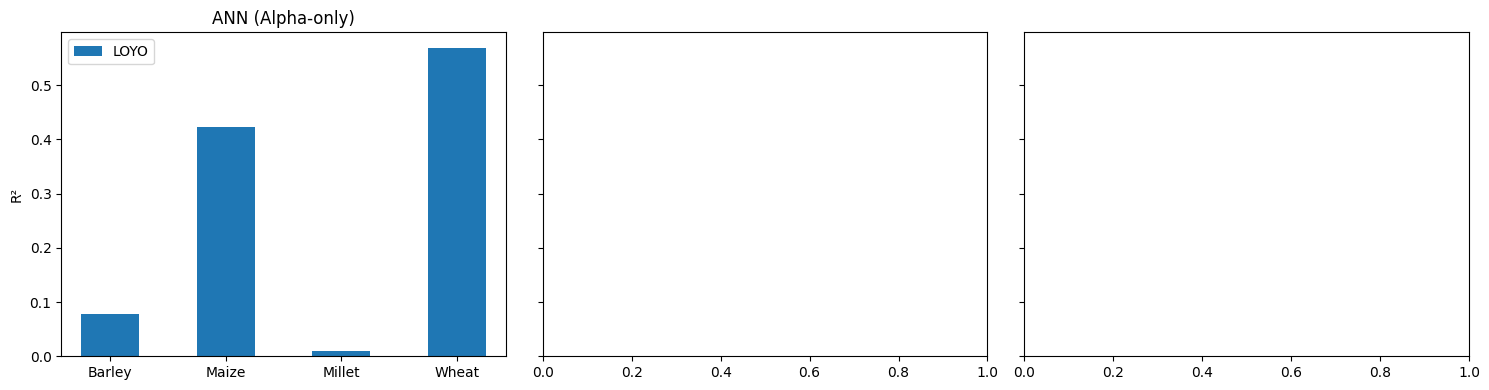

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (dataset_name, df) in zip(axes, results_ann.items()):
    x = np.arange(len(df))
    ax.bar(x, df['LOYO_R2'], width=0.5, label='LOYO')
    ax.set_xticks(x)
    ax.set_xticklabels(df['Crop'])
    ax.set_title(f'ANN ({dataset_name})')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_ylabel('R\u00b2')
    ax.legend()

plt.tight_layout()
plt.savefig('ann_loyo_by_dataset.pdf')
plt.show()

## 8. Predicted-vs-actual scatter plots (LODO out-of-fold predictions)

One figure per dataset, one subplot per crop — shows where errors concentrate
(e.g. systematic under-prediction at high yields), same purpose as the
predicted-vs-actual figure recommended for the paper's Results section.


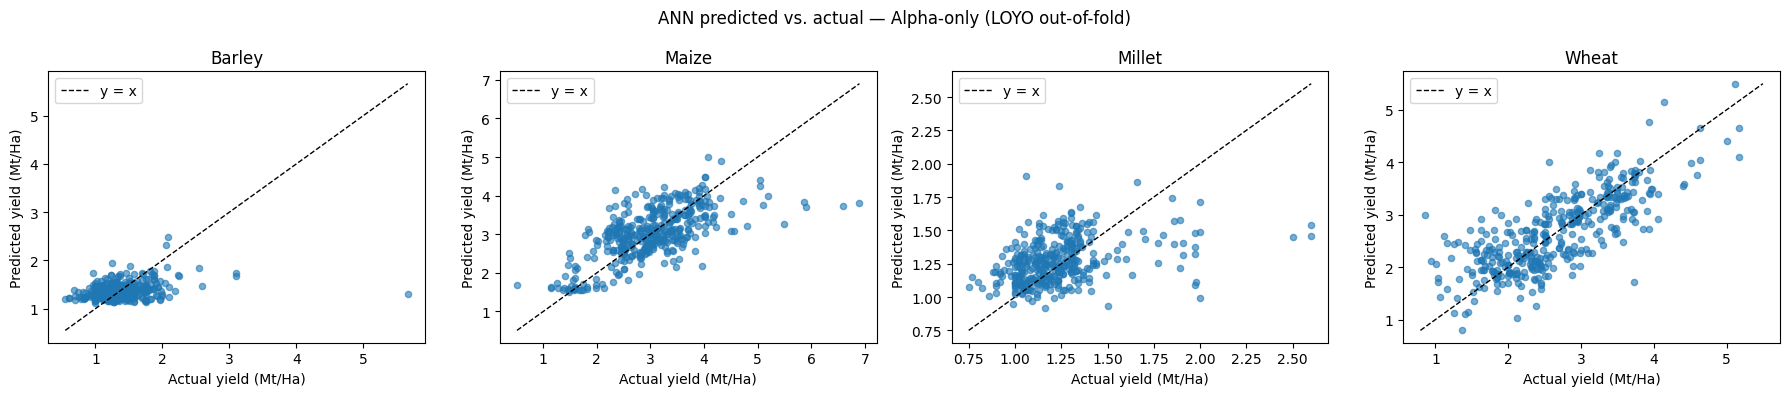

In [9]:
for dataset_name in DATASET_PATHS:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f'ANN predicted vs. actual — {dataset_name} (LOYO out-of-fold)')
    for ax, crop in zip(axes, CROPS):
        y_true, y_pred = loyo_oof_ann[dataset_name][crop]
        ax.scatter(y_true, y_pred, alpha=0.6, s=20)
        lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
        ax.plot(lims, lims, 'k--', linewidth=1, label='y = x')
        ax.set_xlabel('Actual yield (Mt/Ha)')
        ax.set_ylabel('Predicted yield (Mt/Ha)')
        ax.set_title(crop)
        ax.legend()
    plt.tight_layout()
    plt.savefig(f'ann_pred_vs_actual_{dataset_name.replace("-", "_").lower()}.pdf')
    plt.show()

## 9. Combine with your Ridge/RF/XGBoost results

Add an 'ANN' row to each of Tables I–III by concatenating:

```python
results_ann['Soil-only']['Model'] = 'ANN'
results_ann['Combined']['Model'] = 'ANN'
results_ann['AlphaEarth-only']['Model'] = 'ANN'
# then pd.concat([existing_table_i, results_ann['Soil-only']], ignore_index=True), etc.
```

Note for the Methodology: state that ANN feature selection used a permutation-
importance-based elimination (Section 3 above) rather than sklearn's `RFECV`,
since `MLPRegressor` has no `coef_`/`feature_importances_` for `RFECV` to use —
this differs from how RFECV was applied to the other four models and should be
called out explicitly.
